### Declarations

In [1]:
from google.colab import files
files.upload()
print('Functions & packages imported')

Saving compiled_defs_RF_CHL_GON.ipynb to compiled_defs_RF_CHL_GON.ipynb
Functions & packages imported


In [2]:
import os
#os.remove("compiled_defs_RF_CHL_GON.ipynb")

In [3]:
!pip install mat73
!pip install netCDF4
!pip install windrose
!pip install gsw
!pip install seawater

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 79.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 8.5 MB/s eta 0:00:00


In [4]:
%run compiled_defs_RF_CHL_GON.ipynb

/tmp/ipykernel_2692/3134712253.py:16: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


In [5]:
### To use for a correct R2
import numpy as np
from scipy import stats
from sklearn.metrics import (
    mean_absolute_error,
    median_absolute_error,
    mean_squared_error,
    r2_score,
    explained_variance_score,
    mean_absolute_percentage_error
)

def get_metrucs(A, P, ROUND=True, NR=3, PRINT=False):
    A = np.asarray(A, dtype=float).ravel()
    P = np.asarray(P, dtype=float).ravel()

    mask = np.isfinite(A) & np.isfinite(P)
    A = A[mask]
    P = P[mask]

    if len(A) < 3:
        return [np.nan] * 15

    MAE = mean_absolute_error(A, P)
    MEDAE = median_absolute_error(A, P)
    MAXE = np.nanmax(np.abs(A - P))
    MSE = mean_squared_error(A, P)
    RMSE = np.sqrt(MSE)

    if np.any(A == 0):
        MAPE = np.nan
    else:
        MAPE = mean_absolute_percentage_error(A, P)

    RSQU = r2_score(A, P)
    EXVA = explained_variance_score(A, P)

    PEAR, PEAV = stats.pearsonr(A, P)

    lin = stats.linregress(A, P)
    CF = lin.intercept
    SL = lin.slope
    SE = lin.stderr
    PV = lin.pvalue
    R2 = lin.rvalue ** 2

    vals = [MAE, MEDAE, MAXE, MSE, RMSE, MAPE,
            RSQU, EXVA, PEAR, PEAV, R2, PV, CF, SL, SE]

    if ROUND:
        vals = [np.round(v, NR) if np.isfinite(v) else np.nan for v in vals]

    if PRINT:
        print("Pearson:", vals[8])
        print("p-value:", vals[9])
        print("R2 score:", vals[6])
        print("Explained variance:", vals[7])
        print("MAE:", vals[0])
        print("MEDAE:", vals[1])
        print("RMSE:", vals[4])

    return vals

### Load Dataframe for ML

In [6]:
!rm -f df_FOR_ML_bgcTrue*.csv
!rm -f df_FOR_ML_bgcFalse*.csv

In [7]:
from google.colab import files
files.upload()
print('Dataframe loaded')

Saving df_FOR_ML_bgcFalse.csv to df_FOR_ML_bgcFalse.csv
Saving df_FOR_ML_bgcTrue.csv to df_FOR_ML_bgcTrue.csv
Dataframe loaded


In [8]:
import pandas as pd
WITH_BGC = True
WITH_BGC = False
df_FOR_ML = pd.read_csv('df_FOR_ML_bgc'+str(WITH_BGC)+'.csv')
d = df_FOR_ML.copy()
print('WITH_BGC',WITH_BGC,'\n',d.columns, d.shape)

WITH_BGC False 
 Index(['mc_mc', 'dates_mc', 'wy', 'dy', 'ts', 'dd', 'mm', 'yyyy', 'datetime',
       'timestamp', 'chl', 'P-E', 'Precip', 'CumPrecip', 'u', 'v', 'wdir',
       'uuvv', 'u1', 'v1', 'wdir1', 'uuvv1', 'u3', 'v3', 'wdir3', 'uuvv3',
       'sumu3', 'sumv3', 'sumuuvv3', 'PREC_cmcc', 'CPREC_cmcc', 'ppppp_cmcc',
       'MLD', 'LE', 'LE_STAR', 'LC', 'LC_STAR', 'LEC', 'LEC_STAR', 'BIGV',
       'CRI', 'FRWC', 'FP', 'FRSH', 'N1bulk', 'N1meanA', 'Tsurf', 'Sref',
       'Sbottom', 'SmaxSummer', 'Smodel0', 'Smodel00', 'Smodel1', 'Smodel11',
       'Smodel2', 'Smodel22', 'Smodel3', 'Smodel33', 'Smodel4', 'Smodel44',
       'Smodel5', 'Smodel55', 'Smodel6', 'Smodel66', 'Smodel7', 'Smodel77',
       'Smodel1_fp', 'Smodel11_fp', 'Smodel2_fp', 'Smodel22_fp', 'Smodel3_fp',
       'Smodel33_fp', 'Smodel4_fp', 'Smodel44_fp', 'Smodel5_fp', 'Smodel55_fp',
       'Smodel6_fp', 'Smodel66_fp', 'Smodel7_fp', 'Smodel77_fp', 'Ssurface',
       'Tsurface', 'FW', 'FR', 'chl10', 'season'],
      dtype

In [9]:
feats_list_raw = [
    'wy', 'yyyy', 'mc_mc', 'dates_mc', 'datetime',
    'chl', 'chl10',
    'MLD', 'LE', 'LE_STAR', 'LC', 'LC_STAR', 'LEC', 'LEC_STAR',
    'BIGV', 'CRI', 'FW', 'FR', 'FP',
    'u', 'v', 'wdir', 'uuvv',
    'u3', 'v3', 'wdir3', 'uuvv3', 'sumu3', 'sumv3', 'sumuuvv3',
    'u1', 'v1', 'wdir1', 'uuvv1',
    'P-E', 'Precip', 'CumPrecip',
    'PREC_cmcc', 'CPREC_cmcc', 'ppppp_cmcc',
    'SmaxSummer','Sbottom', 'Ssurface', 'Tsurface',
    'N1meanA', 'N1bulk'
]

feats_list_bgc= [
    'doxy', 'amon', 'ntra', 'ntri', 'dino', 'phos', 'slca', 'dino+0.5chl','ntri+0.5chl', 'ntra+0.5chl',
    'doxy10', 'amon10', 'ntra10', 'ntri10', 'dino10', 'phos10', 'slca10', 'dino+0.5chl10','ntri+0.5chl10', 'ntra+0.5chl10'
    ]

if WITH_BGC == True :
  feats_list_raw = feats_list_raw + feats_list_bgc


# remove duplicates while preserving order
feats_list = list(dict.fromkeys(feats_list_raw))

label_stri = 'chl10'

# checks
missing_feats = [c for c in feats_list if c not in d.columns]
missing_label = label_stri not in d.columns

print("Missing feats:", missing_feats)
print("Missing label:", missing_label)

# build dataframes
feats = d[feats_list].copy()
label = d[[label_stri]].copy()
feats.insert(len(feats.columns), 'index', np.arange(len(feats)).astype(int))

print(feats.shape)
print(list(feats.columns))
print('\nlabel:', label_stri, label.shape)

Missing feats: []
Missing label: False
(839, 47)
['wy', 'yyyy', 'mc_mc', 'dates_mc', 'datetime', 'chl', 'chl10', 'MLD', 'LE', 'LE_STAR', 'LC', 'LC_STAR', 'LEC', 'LEC_STAR', 'BIGV', 'CRI', 'FW', 'FR', 'FP', 'u', 'v', 'wdir', 'uuvv', 'u3', 'v3', 'wdir3', 'uuvv3', 'sumu3', 'sumv3', 'sumuuvv3', 'u1', 'v1', 'wdir1', 'uuvv1', 'P-E', 'Precip', 'CumPrecip', 'PREC_cmcc', 'CPREC_cmcc', 'ppppp_cmcc', 'SmaxSummer', 'Sbottom', 'Ssurface', 'Tsurface', 'N1meanA', 'N1bulk', 'index']

label: chl10 (839, 1)


In [10]:
rename_dict = {
    'chl': 'CHL',
    'chl10': 'log10(CHL)',
    'LE': 'LE',
    'LE_STAR': 'LEclim',
    'SmaxSummer': 'S+',
    'Ssurface': 'S',
    'Tsurface': 'T',
    'uuvv': '|U|',
    'wdir': 'WD',
    'PREC_cmcc':'P',

    'doxy': 'DOXY',
    'amon': 'AMON',
    'ntra': 'NTRA',
    'ntri': 'NTRI',
    'dino': 'DINO',
    'phos': 'PHOS',
    'slca': 'SLCA',
    'dino+0.5chl': 'DINO+0.5CHL',
    'ntri+0.5chl': 'NTRI+0.5CHL',
    'ntra+0.5chl': 'NTRA+0.5CHL',

    'doxy10': 'log10(DOXY)',
    'amon10': 'log10(AMON)',
    'ntra10': 'log10(NTRA)',
    'ntri10': 'log10(NTRI)',
    'dino10': 'log10(DINO)',
    'phos10': 'log10(PHOS)',
    'slca10': 'log10(SLCA)',
    'dino+0.5chl10': 'log10(DINO+0.5CHL)',
    'ntri+0.5chl10': 'log10(NTRI+0.5CHL)',
    'ntra+0.5chl10': 'log10(NTRA+0.5CHL)',
}

missing = [k for k in rename_dict if k not in feats.columns]
if len(missing) > 0:
    print("Warning missing columns:", missing)

feats = feats.rename(columns=rename_dict)
feats_list = list(feats.columns)
print("Renamed columns OK")

Warning missing columns: ['doxy', 'amon', 'ntra', 'ntri', 'dino', 'phos', 'slca', 'dino+0.5chl', 'ntri+0.5chl', 'ntra+0.5chl', 'doxy10', 'amon10', 'ntra10', 'ntri10', 'dino10', 'phos10', 'slca10', 'dino+0.5chl10', 'ntri+0.5chl10', 'ntra+0.5chl10']
Renamed columns OK


### NORMALIZATIONS [0-1]

In [11]:
def normalize_01_safe(s):
    s = pd.to_numeric(s, errors="coerce")
    vmin, vmax = s.min(skipna=True), s.max(skipna=True)
    if pd.isna(vmin) or pd.isna(vmax) or vmax == vmin:
        return s * np.nan
    return (s - vmin) / (vmax - vmin)

In [12]:
feats_norm = feats.copy()

num_cols = feats.select_dtypes(include=[np.number]).columns

for col in num_cols:
    feats_norm[col] = normalize_01_safe(feats[col])
print("normalized numeric columns:", len(num_cols))
print("feats:", feats.shape)
print("feats_norm:", feats_norm.shape)


# --- aligned dropna, safer than dropping separately ---
valid_index = feats.dropna().index.intersection(feats_norm.dropna().index)

feats = feats.loc[valid_index].copy()
feats_norm = feats_norm.loc[valid_index].copy()

print("after aligned dropna")
print("feats:", feats.shape)
print("feats_norm:", feats_norm.shape)


normalized numeric columns: 45
feats: (839, 47)
feats_norm: (839, 47)
after aligned dropna
feats: (839, 47)
feats_norm: (839, 47)


In [13]:
feats.columns

Index(['wy', 'yyyy', 'mc_mc', 'dates_mc', 'datetime', 'CHL', 'log10(CHL)',
       'MLD', 'LE', 'LEclim', 'LC', 'LC_STAR', 'LEC', 'LEC_STAR', 'BIGV',
       'CRI', 'FW', 'FR', 'FP', 'u', 'v', 'WD', '|U|', 'u3', 'v3', 'wdir3',
       'uuvv3', 'sumu3', 'sumv3', 'sumuuvv3', 'u1', 'v1', 'wdir1', 'uuvv1',
       'P-E', 'Precip', 'CumPrecip', 'P', 'CPREC_cmcc', 'ppppp_cmcc', 'S+',
       'Sbottom', 'S', 'T', 'N1meanA', 'N1bulk', 'index'],
      dtype='object')

### RUN DOOMFOREST

In [14]:
for var in list(globals()):
    if var.startswith("rf_for_"):
        del globals()[var]

In [15]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
# in case WITH_BGC == True : Initial RF with all bgc feats (but less points)
experience = 'CORE'
RUN_LIST = []
RUN_LIST.append([['log10(CHL)'],['T','S',
                  'DOXY', 'AMON', 'NTRA', 'NTRI', 'DINO', 'PHOS', 'SLCA',
                  'P','FW','MLD','|U|','WD'],2,1/3,'','C00'])

In [ ]:
# to produce the Tab. 1
# need  WITH_BGC == False (reload the proper dataframe) to maximize the number of points (but can be done in the notebook Extra)

experience = 'TRAININGS'
RUN_LIST = []
RUN_LIST.append([['S'],['S+','P','FW','MLD','|U|','WD'],2,1/3,'' ,'S00'])
RUN_LIST.append([['S'],[         'FW','MLD','|U|','WD'],2,1/3,'' ,'S0'])
RUN_LIST.append([['S'],[         'FR','LEclim','|U|','WD'],2,1/3,'' ,'S1'])
RUN_LIST.append([['S'],[         'FP','LEclim','|U|','WD'],2,1/3,'' ,'S2'])
RUN_LIST.append([['S'],[     'P'     ,'LEclim','|U|','WD'],2,1/3,'' ,'S3'])
RUN_LIST.append([['S'],[     'P'     ,      '|U|','WD'],2,1/3,'' ,'S4'])

RUN_LIST.append([['log10(CHL)'],['S','FW','MLD','|U|','WD'],2,1/3,'','C0'])
RUN_LIST.append([['log10(CHL)'],['S','FR','LEclim','|U|','WD'],2,1/3,'','C1'] )
RUN_LIST.append([['log10(CHL)'],['S','FP','LEclim','|U|','WD'],2,1/3,'','C2'] )
RUN_LIST.append([['log10(CHL)'],['S','P' ,'LEclim','|U|','WD'],2,1/3,'','C3'])
RUN_LIST.append([['log10(CHL)'],['S','P'       ,'|U|','WD'],2,1/3,'','C4'])

RUN_LIST.append([['S'],         [       'FR','LEclim','|U|','WD'],2,1/3,'rf_for_SSTAR','S*'] )
RUN_LIST.append([['log10(CHL)'],['S*' ,'FR','LEclim','|U|','WD'],2,1/3,'rf_for_CSTAR','C*'] )

#RUN_LIST.append([['S'],         [       'FP','LEclim','|U|','WD'],2,1/3,'rf_for_SSTARSTAR','S**'] )
#RUN_LIST.append([['log10(CHL)'],['S**RF' ,'FP','LEclim','|U|','WD'],2,1/3,'rf_for_CSTARSTAR','C**'] )


In [16]:
# Essential for the proj only
# need  WITH_BGC == False (reload the proper dataframe) to maximize the number of points

experience = 'PAPER'
RUN_LIST = []
RUN_LIST.append([['S'],         [       'FR','LEclim','|U|','WD'],2,1/3,'rf_for_SSTAR','S*'] )
RUN_LIST.append([['log10(CHL)'],['S*' ,'FR','LEclim','|U|','WD'],2,1/3,'rf_for_CSTAR','C*'] )

In [17]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

RUN_OUT = []
RF_MODELS = {}

n_estimators = 100
rs = np.array([1092, 7288, 6723, 5953, 519, 435, 4297, 1965, 8758, 4943, 4461,
               9932, 2248, 6082, 1712, 9054, 8759, 8150, 4500, 4198, 5987, 9296,
               8902, 207, 8910, 2158, 972, 8582, 2861, 1320, 2482, 8837, 2429,
               4036, 4378, 2837, 1583, 5329, 3458, 1047, 9263, 8682, 9834, 3798,
               5546, 4633, 36, 5940, 9215, 498, 200, 972, 8591, 6979, 4483,
               4985, 9662, 8110, 7154, 7825, 2634, 753, 8591, 7844, 9757, 3242,
               9270, 746, 2161, 2976, 9575, 8217, 3256, 2539, 4135, 5915, 3916,
               4476, 6962, 4687, 5540, 6551, 9033, 3002, 2518, 3013, 5443, 2856,
               9495, 7665, 3800, 6267, 3700, 3466, 5822, 564, 28, 5077, 9099,
               5257])
TN = np.arange(len(rs))

for r in range(len(RUN_LIST)):

    learning_variable = RUN_LIST[r][0]
    training_sub_list = RUN_LIST[r][1]
    TAKENORM = RUN_LIST[r][2]
    test_size = RUN_LIST[r][3]
    note = RUN_LIST[r][4]
    trnm = RUN_LIST[r][5]

    label_stri = learning_variable[0]

    if len(note) == 0:
        note = "rf_for_X"

    str_rf = note

    if label_stri == "CHL":
        clr_var = clr_chl
        label_var = "$Chl_{a}$ $(mg \\ m^{-3})$"
    elif label_stri == "log10(CHL)":
        clr_var = clr_chl
        label_var = "$Chl_{a}$ $log_{10}(mg \\ m^{-3})$"
    elif label_stri == "S":
        clr_var = clr_sal
        label_var = "$S_{A}$ $(g \\ kg^{-1})$"
    else:
        clr_var = "#ff5996"
        label_var = label_stri

    if TAKENORM == 1:
        feats_INPUT = feats_norm.copy()
        label_INPUT = feats_norm[[label_stri]].copy()
    elif TAKENORM == 2:
        feats_INPUT = feats_norm.copy()
        label_INPUT = feats[[label_stri]].copy()
    else:
        feats_INPUT = feats.copy()
        label_INPUT = feats[[label_stri]].copy()

    missing = [c for c in training_sub_list + ["index"] if c not in feats_INPUT.columns]
    if missing:
        raise KeyError(f"Missing columns for {trnm}: {missing}")

    feats_sub_all = feats_INPUT[training_sub_list]
    index_all = np.array(feats_INPUT["index"])
    label_all = np.array(label_INPUT[label_stri])

    SCORE = []
    IMPOR = []

    METRIC_PEAR = []
    METRIC_PEAV = []
    METRIC_RSQU = []
    METRIC_EXVA = []
    METRIC_MAE = []
    METRIC_MEDAE = []
    METRIC_MSE = []
    METRIC_RMSE = []
    METRIC_MAPE = []

    RF_MODELS[str_rf] = []

    for tn, random_state in enumerate(rs):

        feats_train, feats_valid, label_train, label_valid = train_test_split(
            feats_INPUT,
            label_INPUT,
            test_size=test_size,
            random_state=int(random_state)
        )

        index_valid = np.array(feats_valid["index"])

        feats_sub_train = feats_train[training_sub_list]
        feats_sub_valid = feats_valid[training_sub_list]

        Nall = feats_sub_all.shape[0]
        Ntra = feats_sub_train.shape[0]
        Nval = feats_sub_valid.shape[0]

        rf = RandomForestRegressor(
            n_estimators=n_estimators,
            random_state=int(random_state),
            oob_score=True
        )

        rf.fit(feats_sub_train, np.ravel(label_train.values))

        RF_MODELS[str_rf].append(rf)

        SCORE.append(rf.score(feats_sub_valid, label_valid) * 100)
        IMPOR.append(100 * np.round(rf.feature_importances_, 5))

        pred = rf.predict(feats_sub_valid)

        isort = np.argsort(index_valid)
        y_valid = np.array(label_valid)[isort].flatten()
        y_pred = np.array(pred)[isort].flatten()

        MAE, MEDAE, MAXE, MSE, RMSE, MAPE, RSQU, EXVA, PEAR, PEAV, R2, PV, CF, SL, SE = get_metrucs(
            y_valid, y_pred, True, 3, False
        )

        METRIC_PEAR.append(PEAR)
        METRIC_PEAV.append(PEAV)
        METRIC_RSQU.append(RSQU)
        METRIC_EXVA.append(EXVA)
        METRIC_MAE.append(MAE)
        METRIC_MEDAE.append(MEDAE)
        METRIC_MSE.append(MSE)
        METRIC_RMSE.append(RMSE)
        METRIC_MAPE.append(MAPE)

    IMPOR = np.array(IMPOR)

    m0 = np.nanmean(SCORE)
    m1 = np.nanmean(METRIC_PEAR)
    m2 = np.nanmean(METRIC_PEAV)
    m3 = np.nanmean(METRIC_RSQU)
    m4 = np.nanmean(METRIC_EXVA)
    m5 = np.nanmean(METRIC_MAE)
    m6 = np.nanmean(METRIC_MEDAE)
    m7 = np.nanmean(METRIC_MSE)
    m8 = np.nanmean(METRIC_RMSE)
    m9 = np.nanmean(METRIC_MAPE)

    PROJ = np.empty((len(RF_MODELS[str_rf]), feats_sub_all.shape[0])) * np.nan

    for tn, rf in enumerate(RF_MODELS[str_rf]):
        PROJ[tn, :] = rf.predict(feats_sub_all)

    proj = np.nanmean(PROJ, axis=0)

    if label_stri == "S":
        if trnm == "S*":
            col = "S*"
        elif trnm == "S**":
            col = "S**"
        else:
            col = "S_from_RF"

        feats[col] = proj
        feats_norm[col] = normalize_01_safe(feats[col]) # normalize_01

        feats["dS"] = np.array(feats["S"]) - proj
        feats_norm["dS"] = normalize_01_safe(feats["dS"])

    impor = np.nanmean(IMPOR, axis=0)
    impor_std = np.nanstd(IMPOR, axis=0)

    io = np.argsort(impor)[::-1]
    impor = impor[io]
    impor_std = impor_std[io]
    names = np.array(training_sub_list)[io]

    RUN_OUT.append([
        trnm, label_stri, note, training_sub_list,
        TAKENORM, test_size, n_estimators, Nall, Ntra, Nval,
        proj,
        label_all,
        np.array(feats["dates_mc"]).astype("datetime64"),
        np.array(feats["yyyy"]),
        impor, impor_std, names,
        m0, m1, m2, m3, m4, m5, m6, m7, m8, m9,
        rs,
        label_var,
        clr_var
    ])

    print(r, trnm, label_stri, "Pearson:", np.round(m1, 3), training_sub_list)

col_heads = [
    "Training", "Target", "Note", "Predictors",
    "Norm PredTarg No|Yes|YesNo", "%ForTest",
    "Ntrees", "Nall", "Ntraining", "Ntest",
    "Projection", "ObsAll", "Dates", "Years",
    "Importances", "Importances STD", "ImporNames",
    "ScoreRF", "Pearson", "p-v", "R2", "ExplainedVar",
    "MAE", "MEDAE", "MSE", "RMSE", "MAPE",
    "Seeds", "LabelVar", "Color"
]

R = pd.DataFrame(RUN_OUT, columns=col_heads)

S = R[[
    "Training", "Target", "Note", "Predictors",
    "Norm PredTarg No|Yes|YesNo", "%ForTest", "Ntrees",
    "Nall", "Ntraining", "Ntest",
    "Importances", "Importances STD", "ImporNames",
    "ScoreRF", "Pearson", "p-v", "R2", "ExplainedVar",
    "MAE", "MEDAE", "MSE", "RMSE", "MAPE"
]]

R.to_csv(experience + "_R.csv", index=False)
S.to_csv(experience + "_S.csv", index=False)
feats.to_csv(experience + "_feats.csv", index=False)
feats_norm.to_csv(experience + "_feats_norm.csv", index=False)

files.download(experience + "_R.csv")
files.download(experience + "_S.csv")
files.download(experience + "_feats.csv")
files.download(experience + "_feats_norm.csv")

0 S* S Pearson: 0.49 ['FR', 'LEclim', '|U|', 'WD']
1 C* log10(CHL) Pearson: 0.55 ['S*', 'FR', 'LEclim', '|U|', 'WD']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
import glob
uploaded = files.upload()
score_files = sorted(glob.glob("*_S.csv"))
df1 = pd.read_csv("CORE_S.csv")
df2 = pd.read_csv("TRAININGS_S.csv")
scores = pd.concat([df1, df2], axis=0, ignore_index=True)
cols_keep = [
    "Training", "Target", "Predictors",
     "Pearson", "R2",
    "MAE", "MEDAE"]
table1 = scores[cols_keep].copy()
table1.to_csv("TAB1.csv", index=False)
table1.to_excel("TAB1.xlsx", index=False)
files.download("TAB1.csv")
files.download("TAB1.xlsx")
table1

Saving CORE_S.csv to CORE_S (1).csv
Saving TRAININGS_S.csv to TRAININGS_S (2).csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,Training,Target,Predictors,Pearson,R2,MAE,MEDAE
0,C00,log10(CHL),"['T', 'S', 'DOXY', 'AMON', 'NTRA', 'NTRI', 'DI...",0.75346,0.56022,0.22716,0.18826
1,S00,S,"['S+', 'P', 'FW', 'MLD', '|U|', 'WD']",0.95181,0.90355,0.07484,0.05692
2,S0,S,"['FW', 'MLD', '|U|', 'WD']",0.82712,0.67935,0.14468,0.11303
3,S1,S,"['FR', 'LEclim', '|U|', 'WD']",0.48988,0.21307,0.22512,0.17766
4,S2,S,"['FP', 'LEclim', '|U|', 'WD']",0.29775,0.03062,0.25375,0.20454
5,S3,S,"['P', 'LEclim', '|U|', 'WD']",0.30457,0.03769,0.25300,0.20647
6,S4,S,"['P', '|U|', 'WD']",0.28865,0.01004,0.25617,0.20738
7,C0,log10(CHL),"['S', 'FW', 'MLD', '|U|', 'WD']",0.59689,0.34264,0.27657,0.22629
8,C1,log10(CHL),"['S', 'FR', 'LEclim', '|U|', 'WD']",0.59636,0.34556,0.27960,0.23429
9,C2,log10(CHL),"['S', 'FP', 'LEclim', '|U|', 'WD']",0.58590,0.33145,0.28254,0.23627


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt

def plot_rf_run(R, i, experience, fig_export_dir="", dpi=600):
    row = R.iloc[i]
    fs = 18
    trnm = row["Training"]
    label_stri = row["Target"]
    training_sub_list = row["Predictors"]
    test_size = row["%ForTest"]

    proj = np.asarray(row["Projection"])
    y_all = np.asarray(row["ObsAll"])
    dt = np.asarray(row["Dates"]).astype("datetime64")
    years = np.asarray(row["Years"])

    impor = np.asarray(row["Importances"])
    impor_std = np.asarray(row["Importances STD"])
    names = np.asarray(row["ImporNames"])

    m1 = row["Pearson"]
    m2 = row["p-v"]
    m3 = row["R2"]
    m5 = row["MAE"]
    m6 = row["MEDAE"]

    label_var = row["LabelVar"]
    clr_var = row["Color"]

    period_ia = np.arange(2001, 2020 + 1, 1)
    dt_ia = np.array([datetime(y, 6, 1) for y in period_ia])
    obs_ia = beaning_median(y_all, period_ia, years)
    rfo_ia = beaning_median(proj, period_ia, years)

    out_name = (
        "run_" + str(i) + "_" + trnm + "_" + label_stri + "_" +
        str(len(training_sub_list)) + "FEATS" +
        "_PEAR" + str(int(1000 * np.round(m1, 3))) +
        "_MAE" + str(int(1000 * np.round(m5, 3)))
    )

   # fig_filename = experience + "_" + out_name + "_FULL.png"
    safe_out_name = out_name.replace("*", "STAR")
    fig_filename = experience + "_" + safe_out_name + "_FULL.png"

    fig, axs = plt.subplots(1, 4, figsize=(14, 3))

    ax = axs[0]
    x = np.arange(len(impor))
    ax.bar(x, impor, color=clr_var, alpha=.5)
    ax.errorbar(x, impor, yerr=impor_std, fmt="none", ecolor="k", lw=2, alpha=.5)
    ax.set_xticks(x)
    ax.set_xticklabels(names, fontsize=10, rotation=60, ha="right")
    ax.set_ylabel("Importance (%)")
    #ax.set_title("a) Importances", loc="left",fontsize=fs)

    score_txt = (
        f"Train/Test: {round(100 * (1 - test_size))}/{round(100 * test_size)}%\n"
        f"Pearson = {np.round(m1, 3)}\n"
        #f"p = {np.round(m2, 3)}\n"
        f"R² = {np.round(m3, 3)}\n"
        f"MAE = {np.round(m5, 3)}\n"
        f"MedAE = {np.round(m6, 3)}"
    )
    ax.text(
        0.98, 0.98, score_txt,
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=8.5,
        bbox=dict(facecolor="white", edgecolor="none", alpha=.75)
    )

    ax = axs[1]
    ax.plot(dt, y_all, "-", color="gray", alpha=.8, label="Obs.")
    ax.plot(dt, proj, "-", color=clr_var, alpha=1, label="RF")
    ax.set_xlim(datetime(2010, 1, 1), datetime(2015, 1, 1))
    ax.set_ylabel(label_var)
    #ax.set_title("b) Weekly time series", loc="left",fontsize=fs)
    ax.legend(fontsize=8.5)

    from scipy.stats import gaussian_kde

    ax = axs[2]

    yy_obs = y_all[np.isfinite(y_all)]
    yy_rf = proj[np.isfinite(proj)]

    xmin = np.nanmin([yy_obs.min(), yy_rf.min()])
    xmax = np.nanmax([yy_obs.max(), yy_rf.max()])
    xx = np.linspace(xmin, xmax, 300)

    bw = 0.1

    if len(yy_obs) > 2 and np.nanstd(yy_obs) > 0:
        kde_obs = gaussian_kde(yy_obs, bw_method=bw)
        ax.plot(xx, kde_obs(xx), color="gray", lw=2, label="Obs.")

    if len(yy_rf) > 2 and np.nanstd(yy_rf) > 0:
        kde_rf = gaussian_kde(yy_rf, bw_method=bw)
        ax.plot(xx, kde_rf(xx), color=clr_var, lw=2, label="RF")

    ax.set_xlabel(label_var)
    ax.set_ylabel("Density")
    #ax.set_title("c) PDFs", loc="left")
    ax.legend(fontsize=8.5)

    from matplotlib.dates import YearLocator, DateFormatter

    ax = axs[3]
    ax.plot(dt_ia, obs_ia, "-", color="gray", alpha=.8, lw=1.5, label="Obs.")
    ax.plot(dt_ia, rfo_ia, "-", color=clr_var, alpha=1, lw=1.5, label="RF")
    ax.set_xlim(datetime(2001, 1, 1), datetime(2020, 1, 1))
    ax.set_ylabel(label_var)
    #ax.set_title("d) Interannual", loc="left")
    ax.legend(fontsize=8.5)

    ax.xaxis.set_major_locator(YearLocator(5))
    ax.xaxis.set_major_formatter(DateFormatter('%Y'))

    fig.suptitle("Training " + trnm + "   " + label_var, fontsize=16)
    fig.tight_layout(pad=1)

    if fig_export_dir:
        fig.savefig(fig_export_dir + "runs/" + fig_filename , dpi=dpi, bbox_inches="tight")
    else:
        fig.savefig(fig_filename, dpi=dpi, bbox_inches="tight")

    plt.show()

    return fig_filename

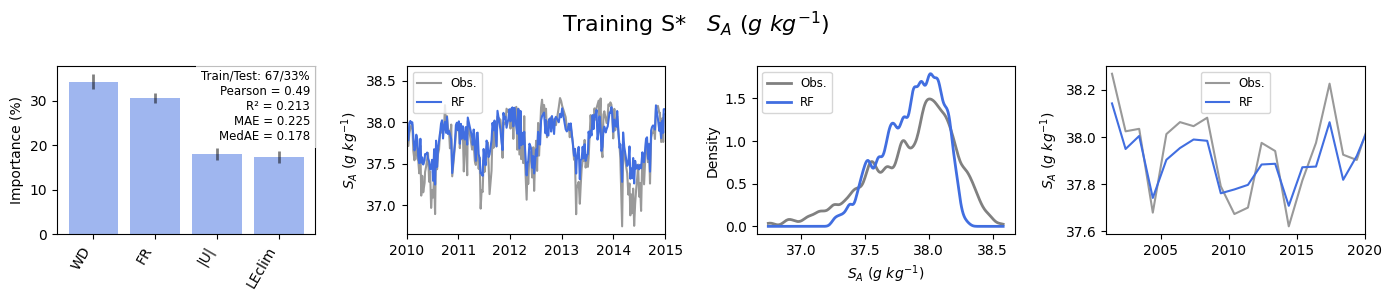

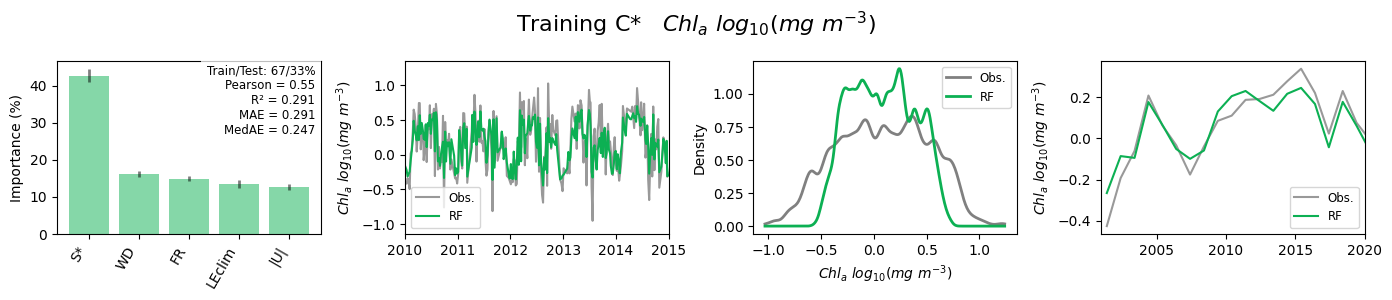

['PAPER_run_0_SSTAR_S_4FEATS_PEAR490_MAE225_FULL.png',
 'PAPER_run_1_CSTAR_log10(CHL)_5FEATS_PEAR550_MAE291_FULL.png']

In [ ]:
np.NaN = np.nan
fig_files = []

for i in range(len(R)):
    fig_files.append(plot_rf_run(R, i, experience, fig_export_dir="", dpi=600))

fig_files

In [ ]:
import zipfile
import os
from google.colab import files

zip_name = "RF_figures_FULL.zip"

with zipfile.ZipFile(zip_name, "w") as z:
    for f in fig_files:
        if os.path.exists(f):
            z.write(f)
        else:
            print("Missing:", f)

files.download(zip_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt

def plot_rf_run(R, i, experience, fig_export_dir="", dpi=600):
    row = R.iloc[i]
    fs = 18
    trnm = row["Training"]
    label_stri = row["Target"]
    training_sub_list = row["Predictors"]
    test_size = row["%ForTest"]

    proj = np.asarray(row["Projection"])
    y_all = np.asarray(row["ObsAll"])
    dt = np.asarray(row["Dates"]).astype("datetime64")
    years = np.asarray(row["Years"])

    impor = np.asarray(row["Importances"])
    impor_std = np.asarray(row["Importances STD"])
    names = np.asarray(row["ImporNames"])

    m1 = row["Pearson"]
    m2 = row["p-v"]
    m3 = row["R2"]
    m5 = row["MAE"]
    m6 = row["MEDAE"]

    label_var = row["LabelVar"]
    clr_var = row["Color"]

    period_ia = np.arange(2001, 2020 + 1, 1)
    dt_ia = np.array([datetime(y, 6, 1) for y in period_ia])
    obs_ia = beaning_median(y_all, period_ia, years)
    rfo_ia = beaning_median(proj, period_ia, years)

    out_name = (
        "run_" + str(i) + "_" + trnm + "_" + label_stri + "_" +
        str(len(training_sub_list)) + "FEATS" +
        "_PEAR" + str(int(1000 * np.round(m1, 3))) +
        "_MAE" + str(int(1000 * np.round(m5, 3)))
    )

    safe_out_name = out_name.replace("*", "STAR")
    fig_filename = experience + "_" + safe_out_name + ".png"
    #fig_filename = experience + "_" + out_name + ".png"

    fig, axs = plt.subplots(1, 3, figsize=(11, 4))####-----------

    ax = axs[0]
    x = np.arange(len(impor))
    ax.bar(x, impor, color=clr_var, alpha=.5)
    ax.errorbar(x, impor, yerr=impor_std, fmt="none", ecolor="k", lw=2, alpha=.5)
    ax.set_xticks(x)
    ax.set_xticklabels(names, fontsize=10, rotation=60, ha="right")
    #ax.set_ylabel("Importance (%)")
    ax.set_title('Importance (%)', loc="left")
    #ax.set_title("a) Importances", loc="left",fontsize=fs)

    score_txt = (
        f"Train/Test: {round(100 * (1 - test_size))}/{round(100 * test_size)}%\n"
        f"Pearson = {np.round(m1, 3)}\n"
        #f"p = {np.round(m2, 3)}\n"
        f"R² = {np.round(m3, 3)}\n"
        f"MAE = {np.round(m5, 3)}\n"
        f"MedAE = {np.round(m6, 3)}"
    )
    ax.text(
        0.98, 0.98, score_txt,
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=8.5,
        bbox=dict(facecolor="white", edgecolor="none", alpha=.75)
    )

    ax = axs[1]
    ax.plot(dt, y_all, "-", color="gray", alpha=.8, label="Obs.")
    ax.plot(dt, proj, "-", color=clr_var, alpha=1, label="RF")
    ax.set_xlim(datetime(2010, 1, 1), datetime(2015, 1, 1))
    #ax.set_ylabel(label_var)
    #ax.set_title("b) Weekly time series", loc="left",fontsize=fs)
    ax.legend(fontsize=8.5)
    ax.set_title(label_var, loc="left")
    from scipy.stats import gaussian_kde

    #ax = axs[2]

    #yy_obs = y_all[np.isfinite(y_all)]
    #yy_rf = proj[np.isfinite(proj)]

    #xmin = np.nanmin([yy_obs.min(), yy_rf.min()])
    #xmax = np.nanmax([yy_obs.max(), yy_rf.max()])
    #xx = np.linspace(xmin, xmax, 300)

    #bw = 0.1

    #if len(yy_obs) > 2 and np.nanstd(yy_obs) > 0:
    #    kde_obs = gaussian_kde(yy_obs, bw_method=bw)
    #    ax.plot(xx, kde_obs(xx), color="gray", lw=2, label="Obs.")

    #if len(yy_rf) > 2 and np.nanstd(yy_rf) > 0:
    #    kde_rf = gaussian_kde(yy_rf, bw_method=bw)
    #    ax.plot(xx, kde_rf(xx), color=clr_var, lw=2, label="RF")

    #ax.set_xlabel(label_var)
    #ax.set_ylabel("Density")
    ##ax.set_title("c) PDFs", loc="left")
    #ax.legend(fontsize=8.5)

    from matplotlib.dates import YearLocator, DateFormatter

    ax = axs[2]
    ax.plot(dt_ia, obs_ia, "-", color="gray", alpha=.8, lw=1.5, label="Obs.")
    ax.plot(dt_ia, rfo_ia, "-", color=clr_var, alpha=1, lw=1.5, label="RF")
    ax.set_xlim(datetime(2001, 1, 1), datetime(2020, 1, 1))
    #ax.set_ylabel(label_var)
    ax.set_title(label_var, loc="left")
    ax.legend(fontsize=8.5)

    ax.xaxis.set_major_locator(YearLocator(5))
    ax.xaxis.set_major_formatter(DateFormatter('%Y'))

    fig.suptitle("Training " + trnm + "   " + label_var, fontsize=16)
    fig.tight_layout(pad=1)

    if fig_export_dir:
        fig.savefig(fig_export_dir + "runs/" + fig_filename, dpi=dpi, bbox_inches="tight")
    else:
        fig.savefig(fig_filename, dpi=dpi, bbox_inches="tight")

    plt.show()

    return fig_filename

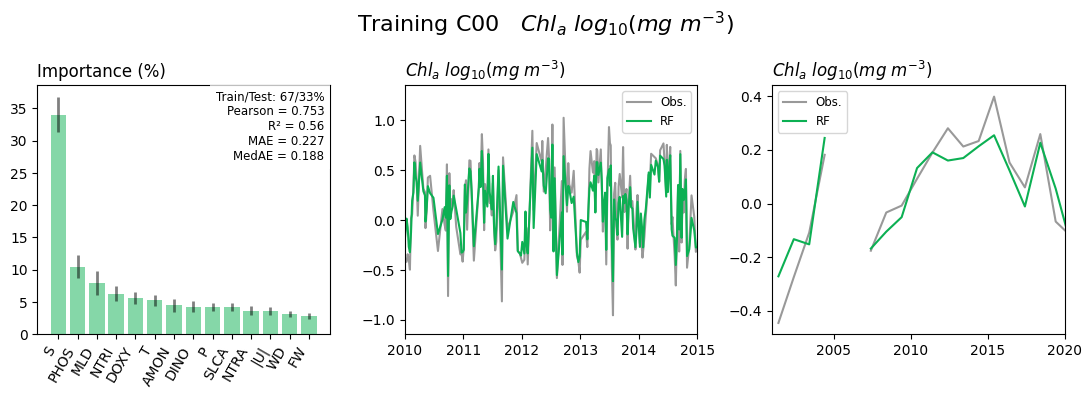

['CORE_run_0_C00_log10(CHL)_14FEATS_PEAR753_MAE227.png']

In [ ]:
np.NaN = np.nan
fig_files = []

for i in range(len(R)):
    fig_files.append(plot_rf_run(R, i, experience, fig_export_dir="", dpi=600))

fig_files

In [ ]:
import zipfile
import os
from google.colab import files

zip_name = "RF_figures.zip"

with zipfile.ZipFile(zip_name, "w") as z:
    for f in fig_files:
        if os.path.exists(f):
            z.write(f)
        else:
            print("Missing:", f)

files.download(zip_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Projections

In [18]:
from google.colab import files
files.upload()
print('Dataframes RCPS uploaded')

Saving df_cmcc_rcp85.csv to df_cmcc_rcp85.csv
Saving df_cmcc_rcp45.csv to df_cmcc_rcp45.csv
Dataframes RCPS uploaded


In [19]:
df_cmcc_rcp45 = pd.read_csv("df_cmcc_rcp45.csv", parse_dates=["datetime"])
df_cmcc_rcp85 = pd.read_csv("df_cmcc_rcp85.csv", parse_dates=["datetime"])
print(df_cmcc_rcp45.shape, df_cmcc_rcp85.shape)

(569784, 10) (569784, 10)


In [20]:
U10M_rcp45 = df_cmcc_rcp45["U10M"].values
V10M_rcp45 = df_cmcc_rcp45["V10M"].values
PREC_rcp45 = df_cmcc_rcp45["PREC"].values
dt_rcp45   = df_cmcc_rcp45["datetime"].values
ts_rcp45   = df_cmcc_rcp45["ts"].values
UUVV_rcp45 = df_cmcc_rcp45["UUVV"].values if "UUVV" in df_cmcc_rcp45.columns else None

U10M_rcp85 = df_cmcc_rcp85["U10M"].values
V10M_rcp85 = df_cmcc_rcp85["V10M"].values
PREC_rcp85 = df_cmcc_rcp85["PREC"].values
dt_rcp85   = df_cmcc_rcp85["datetime"].values
ts_rcp85   = df_cmcc_rcp85["ts"].values
UUVV_rcp85 = df_cmcc_rcp85["UUVV"].values if "UUVV" in df_cmcc_rcp85.columns else None

def compute_uv(U, V):
    UUVV = np.sqrt(U**2 + V**2)
    WDIR = (np.degrees(np.arctan2(V, U)) + 360) % 360
    return UUVV, WDIR

UUVV_rcp45, WDIR_rcp45 = compute_uv(U10M_rcp45, V10M_rcp45)
UUVV_rcp85, WDIR_rcp85 = compute_uv(U10M_rcp85, V10M_rcp85)

def compute_time_vars(dt):
    dt = pd.to_datetime(dt)
    dy   = dt.dayofyear.values
    wy   = dt.isocalendar().week.astype(int).values
    yyyy = dt.year.values
    mm   = dt.month.values
    return wy, dy, yyyy, mm

wy_rcp45, dy_rcp45, yyyy_rcp45, mm_rcp45 = compute_time_vars(dt_rcp45)
wy_rcp85, dy_rcp85, yyyy_rcp85, mm_rcp85 = compute_time_vars(dt_rcp85)

rho_sea = 1026.93
latref = 40.8014
fref = gsw.geostrophy.f(latref)

def compute_ustar(UUVV, rho_sea, z=10., rho_air=1.22, Ta=10.):
    tau = stress(UUVV, z=z, drag='largepond', rho_air=rho_air, Ta=Ta)
    return np.sqrt(tau / rho_sea)

USTAR_rcp45 = compute_ustar(UUVV_rcp45, rho_sea)
USTAR_rcp85 = compute_ustar(UUVV_rcp85, rho_sea)

Clim N


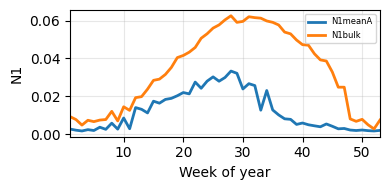

In [21]:
clim_week = (
    d[["wy", "N1bulk", "N1meanA"]]
    .dropna()
    .groupby("wy", as_index=True)
    .median()
    .reindex(np.arange(1, 54))
)

clim_week = clim_week.interpolate(limit_direction="both")

N1_bulk_53 = clim_week["N1bulk"].values
N1_meanA_53 = clim_week["N1meanA"].values

def weekly_clim_to_rcp(wy, clim_53):
    wy = np.asarray(wy).astype(int)
    wy = np.clip(wy, 1, 53)
    return clim_53[wy - 1]

N1_bulk_rcp45 = weekly_clim_to_rcp(wy_rcp45, N1_bulk_53)
N1_bulk_rcp85 = weekly_clim_to_rcp(wy_rcp85, N1_bulk_53)

N1_meanA_rcp45 = weekly_clim_to_rcp(wy_rcp45, N1_meanA_53)
N1_meanA_rcp85 = weekly_clim_to_rcp(wy_rcp85, N1_meanA_53)

print("Clim N")


weeks = np.arange(1, 54)

fig, ax = plt.subplots(figsize=(4, 2))
ax.plot(weeks, N1_meanA_53, lw=2, label="N1meanA")
ax.plot(weeks, N1_bulk_53, lw=2, label="N1bulk")
ax.set_xlabel("Week of year")
ax.set_ylabel("N1")
ax.set_xlim(1, 53)
ax.grid(alpha=0.3)
ax.legend(fontsize=6)
fig.tight_layout()
plt.show()

In [22]:
coef1 = 1.0
coef2 = 1.0

def compute_ekman(USTAR, fref, N1=None, coef1=1.0, coef2=1.0):
    EKS = coef1 * USTAR / fref
    if N1 is not None:
        EKSN = coef2 * USTAR / np.sqrt(fref * N1)
    else:
        EKSN = None
    return EKS, EKSN

EKS_rcp45, EKSN_rcp45 = compute_ekman(USTAR_rcp45, fref, N1_bulk_rcp45, coef1, coef2)
EKS_rcp85, EKSN_rcp85 = compute_ekman(USTAR_rcp85, fref, N1_bulk_rcp85, coef1, coef2)
print("EKMAN CALCULATED")

EKMAN CALCULATED


### weekly averages

In [24]:
np.NaN = np.nan
import numpy as np
import pandas as pd
from datetime import datetime
from scipy.signal.windows import tukey

a = 5.817612621540121
b = 5.354700649547905
NHOURSBEFORE = 24
years_cmcc = np.arange(2006, 2070 + 1, 1)

def weekly_cmcc_block(PREC, U10M, V10M, WDIR, UUVV, EKSN, EKS, yyyy, wy, years, NHOURSBEFORE=24):
    x_out, out_yyyy, out_w, out_k, PREC_w, CPREC_w, ppppp_w = beaning_weekly2(PREC, years, yyyy, wy)
    _, _, _, _, U10M_w, _, _ = beaning_weekly2(U10M, years, yyyy, wy)
    _, _, _, _, V10M_w, _, _ = beaning_weekly2(V10M, years, yyyy, wy)
    _, _, _, _, WDIR_w, _, _ = beaning_weekly2(WDIR, years, yyyy, wy)
    _, _, _, _, UUVV_w, _, _ = beaning_weekly2(UUVV, years, yyyy, wy)
    _, _, _, _, EKSN_w, _ = beaning_weekly_NHOURS(EKSN, years, yyyy, wy, NHOURSBEFORE)
    _, _, _, _, EKS_w, _ = beaning_weekly_NHOURS(EKS, years, yyyy, wy, NHOURSBEFORE)

    EKSN_w = a * EKSN_w + b
    EKSN_w[EKSN_w > 75] = 75

    return {
        "x_out": x_out,
        "yyyy": out_yyyy,
        "wy": out_w,
        "k": out_k,
        "PREC": PREC_w,
        "CPREC": CPREC_w,
        "ppppp": ppppp_w,
        "U10M": U10M_w,
        "V10M": V10M_w,
        "WDIR": WDIR_w,
        "UUVV": UUVV_w,
        "EKSN": EKSN_w,
        "EKS": EKS_w
    }

rcp45_w = weekly_cmcc_block(
    PREC_rcp45, U10M_rcp45, V10M_rcp45, WDIR_rcp45, UUVV_rcp45,
    EKSN_rcp45, EKS_rcp45, yyyy_rcp45, wy_rcp45, years_cmcc, NHOURSBEFORE
)

rcp85_w = weekly_cmcc_block(
    PREC_rcp85, U10M_rcp85, V10M_rcp85, WDIR_rcp85, UUVV_rcp85,
    EKSN_rcp85, EKS_rcp85, yyyy_rcp85, wy_rcp85, years_cmcc, NHOURSBEFORE
)

PREC_rcp45_w = rcp45_w["PREC"]
CPREC_rcp45_w = rcp45_w["CPREC"]
ppppp_rcp45_w = rcp45_w["ppppp"]
U10M_rcp45_w = rcp45_w["U10M"]
V10M_rcp45_w = rcp45_w["V10M"]
WDIR_rcp45_w = rcp45_w["WDIR"]
UUVV_rcp45_w = rcp45_w["UUVV"]
EKSN_rcp45_w = rcp45_w["EKSN"]
EKS_rcp45_w = rcp45_w["EKS"]

PREC_rcp85_w = rcp85_w["PREC"]
CPREC_rcp85_w = rcp85_w["CPREC"]
ppppp_rcp85_w = rcp85_w["ppppp"]
U10M_rcp85_w = rcp85_w["U10M"]
V10M_rcp85_w = rcp85_w["V10M"]
WDIR_rcp85_w = rcp85_w["WDIR"]
UUVV_rcp85_w = rcp85_w["UUVV"]
EKSN_rcp85_w = rcp85_w["EKSN"]
EKS_rcp85_w = rcp85_w["EKS"]

FRSH_rcp45_w = CPREC_rcp45_w ** (1 / 3)
FRSH_rcp85_w = CPREC_rcp85_w ** (1 / 3)

yyyywy_cmcc = rcp45_w["x_out"]
yyyy_cmcc = rcp45_w["yyyy"]
wy_cmcc = rcp45_w["wy"]

mm_cmcc = np.ceil(wy_cmcc / 4.33)
mm_cmcc[mm_cmcc == 13] = 12

dt_cmcc = pd.to_datetime(
    yyyy_cmcc.astype(int).astype(str) + "-W" +
    np.char.zfill(wy_cmcc.astype(int).astype(str), 2) + "-1",
    format="%Y-W%W-%w"
)
ts_cmcc = dt_cmcc.astype("int64") / 1e9
dt_cmcc = dt_cmcc.to_numpy()

print("done x")

/tmp/ipykernel_2692/1421116125.py:223: RuntimeWarning: invalid value encountered in power
  y_out3[k] = np.nanmean(y_in[fiw]**(1/3))
/tmp/ipykernel_2692/1421116125.py:223: RuntimeWarning: Mean of empty slice
  y_out3[k] = np.nanmean(y_in[fiw]**(1/3))


done x


### build dataframes for projections

In [25]:
ADJFAC_P = 1
ADJFAC_p = 1
ADJFAC_H = 1
ADJFAC_FR_LIST = np.linspace(0.3, 0.9, 4) # np.linspace(0.1, 1, 10)

def build_proj_norm(FRSH_w, CPREC_w, PREC_w, EKSN_w, WDIR_w, UUVV_w, ADJFAC_FR_test):
    proj = pd.DataFrame()
    proj["wy"] = wy_cmcc
    proj["FR"] = FRSH_w
    proj["FP"] = FRSH_w
    proj["P"] = CPREC_w
    proj["p"] = PREC_w
    proj["LEclim"] = EKSN_w
    proj["WD"] = WDIR_w
    proj["|U|"] = UUVV_w

    proj_norm = proj.copy()
    proj_norm["wy"] = normalize_01_safe(proj["wy"])
    proj_norm["FR"] = normalize_01_safe(proj["FR"]) * ADJFAC_FR_test
    proj_norm["FP"] = normalize_01_safe(proj["FP"]) * ADJFAC_FR_test
    proj_norm["P"] = normalize_01_safe(proj["P"]) * ADJFAC_P
    proj_norm["p"] = normalize_01_safe(proj["p"]) * ADJFAC_p
    proj_norm["LEclim"] = normalize_01_safe(proj["LEclim"]) * ADJFAC_H
    proj_norm["WD"] = normalize_01_safe(proj["WD"])
    proj_norm["|U|"] = normalize_01_safe(proj["|U|"])

    return proj, proj_norm

In [29]:
OUT = {}

for iadj, ADJFAC_FR_test in enumerate(ADJFAC_FR_LIST):

    proj_rcp45, proj_norm_45 = build_proj_norm(
        FRSH_rcp45_w,
        CPREC_rcp45_w,
        PREC_rcp45_w,
        EKSN_rcp45_w,
        WDIR_rcp45_w,
        UUVV_rcp45_w,
        ADJFAC_FR_test
    )

    proj_rcp85, proj_norm_85 = build_proj_norm(
        FRSH_rcp85_w,
        CPREC_rcp85_w,
        PREC_rcp85_w,
        EKSN_rcp85_w,
        WDIR_rcp85_w,
        UUVV_rcp85_w,
        ADJFAC_FR_test
    )

    for r in range(len(RUN_LIST)):

        label_stri = RUN_LIST[r][0][0]
        list_for = RUN_LIST[r][1]
        str_rf_for = RUN_LIST[r][4]
        run_name = RUN_LIST[r][-1]

        if run_name not in ["S*", "C*"]:
            continue

        if str_rf_for not in RF_MODELS:
            raise KeyError(f"{str_rf_for} missing in RF_MODELS")

        missing_45 = [c for c in list_for if c not in proj_norm_45.columns]
        missing_85 = [c for c in list_for if c not in proj_norm_85.columns]

        if missing_45 or missing_85:
            raise KeyError(f"Missing predictors for {run_name}: rcp45={missing_45}, rcp85={missing_85}")

        models = RF_MODELS[str_rf_for]

        P45 = np.empty((len(models), proj_norm_45[list_for].shape[0])) * np.nan
        P85 = np.empty((len(models), proj_norm_85[list_for].shape[0])) * np.nan

        for tn, rf in enumerate(models):
            P45[tn, :] = rf.predict(proj_norm_45[list_for])
            P85[tn, :] = rf.predict(proj_norm_85[list_for])

        p45 = np.nanmean(P45, axis=0)
        p85 = np.nanmean(P85, axis=0)

        if label_stri == "S" and run_name == "S*":
            proj_rcp45["S*"] = p45
            proj_rcp85["S*"] = p85
            proj_norm_45["S*"] = normalize_01_safe(proj_rcp45["S*"])
            proj_norm_85["S*"] = normalize_01_safe(proj_rcp85["S*"])

        elif label_stri == "log10(CHL)" and run_name == "C*":
            proj_rcp45["CHL_RF"] = p45
            proj_rcp85["CHL_RF"] = p85
            proj_norm_45["CHL_RF"] = normalize_01_safe(proj_rcp45["CHL_RF"])
            proj_norm_85["CHL_RF"] = normalize_01_safe(proj_rcp85["CHL_RF"])

        print(
            "ADJFAC_FR =", np.round(ADJFAC_FR_test, 3),
            "|", run_name,
            "|", label_stri,
            "|", list_for
        )

    OUT[ADJFAC_FR_test] = {
        "proj_rcp45": proj_rcp45.copy(),
        "proj_norm_45": proj_norm_45.copy(),
        "proj_rcp85": proj_rcp85.copy(),
        "proj_norm_85": proj_norm_85.copy(),
        "S_proj_45": np.array(proj_rcp45["S*"]),
        "C_proj_45": np.array(proj_rcp45["CHL_RF"]),
        "S_proj_85": np.array(proj_rcp85["S*"]),
        "C_proj_85": np.array(proj_rcp85["CHL_RF"])
    }

print("done")

ADJFAC_FR = 0.3 | S* | S | ['FR', 'LEclim', '|U|', 'WD']
ADJFAC_FR = 0.3 | C* | log10(CHL) | ['S*', 'FR', 'LEclim', '|U|', 'WD']
ADJFAC_FR = 0.5 | S* | S | ['FR', 'LEclim', '|U|', 'WD']
ADJFAC_FR = 0.5 | C* | log10(CHL) | ['S*', 'FR', 'LEclim', '|U|', 'WD']
ADJFAC_FR = 0.7 | S* | S | ['FR', 'LEclim', '|U|', 'WD']
ADJFAC_FR = 0.7 | C* | log10(CHL) | ['S*', 'FR', 'LEclim', '|U|', 'WD']
ADJFAC_FR = 0.9 | S* | S | ['FR', 'LEclim', '|U|', 'WD']
ADJFAC_FR = 0.9 | C* | log10(CHL) | ['S*', 'FR', 'LEclim', '|U|', 'WD']
done


### Plots projections

In [55]:
out_yyyy  =  yyyy_cmcc
RCP_CHOICE = 45

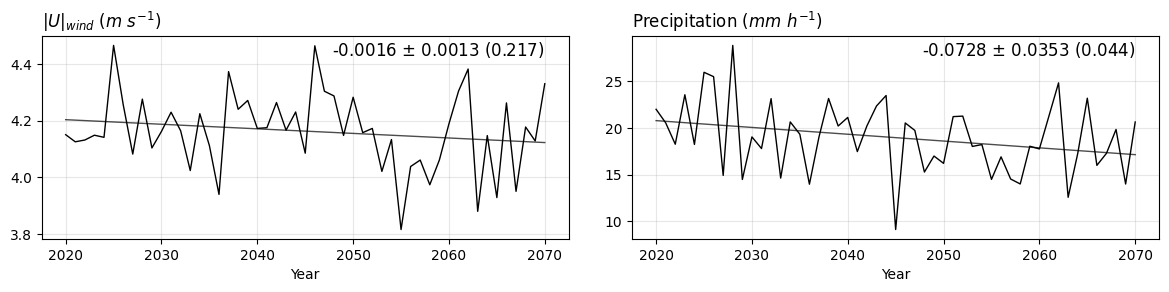

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [56]:
from google.colab import files
import matplotlib.pyplot as plt
import numpy as np

period_ia = np.arange(2020, 2070 + 1)

rcpchoice = RCP_CHOICE
col = "k"

fig, axs = plt.subplots(1, 2, figsize=(12, 3))
ax0, ax2 = axs

if rcpchoice == 45:
    U_ia = beaning(np.array(UUVV_rcp45_w), period_ia, out_yyyy)
    P_ia = beaning(np.array(PREC_rcp45_w), period_ia, out_yyyy)
else:
    U_ia = beaning(np.array(UUVV_rcp85_w), period_ia, out_yyyy)
    P_ia = beaning(np.array(PREC_rcp85_w), period_ia, out_yyyy)

_, _, _, _, _, _, PV_U, SL_U, SE_U, IT_U = get_means_and_trends(period_ia, U_ia, False, 3, False)
_, _, _, _, _, _, PV_P, SL_P, SE_P, IT_P = get_means_and_trends(period_ia, P_ia, False, 3, False)

U_fit = SL_U * period_ia + IT_U
P_fit = SL_P * period_ia + IT_P

ax0.plot(period_ia, U_ia, color=col, linewidth=1)
ax0.plot(period_ia, U_fit, color=col, linewidth=1, alpha=.7)

ax2.plot(period_ia, P_ia, color=col, linewidth=1)
ax2.plot(period_ia, P_fit, color=col, linewidth=1, alpha=.7)

ax0.set_xlabel("Year")
ax2.set_xlabel("Year")

ax0.set_title(r"$|U|_{wind}$ $(m \ s^{-1})$",loc='left')
ax2.set_title(r"Precipitation $(mm \ h^{-1})$",loc='left')

ax0.grid(alpha=0.3)
ax2.grid(alpha=0.3)

txtU = rf"{SL_U:.4f} $\pm$ {SE_U:.4f} ({PV_U:.3f})"
txtP = rf"{SL_P:.4f} $\pm$ {SE_P:.4f} ({PV_P:.3f})"

ax0.text(0.55, 0.98, txtU, transform=ax0.transAxes,
         ha="left", va="top", color=col, fontsize=12)

ax2.text(0.55, 0.98, txtP, transform=ax2.transAxes,
         ha="left", va="top", color=col, fontsize=12)

fig.tight_layout(pad=1)

fig_filename = "FIGURE_PROJ_U_P_rcp" + str(rcpchoice) + ".png"
fig.savefig(fig_filename, dpi=600, bbox_inches="tight")
plt.show()

files.download(fig_filename)

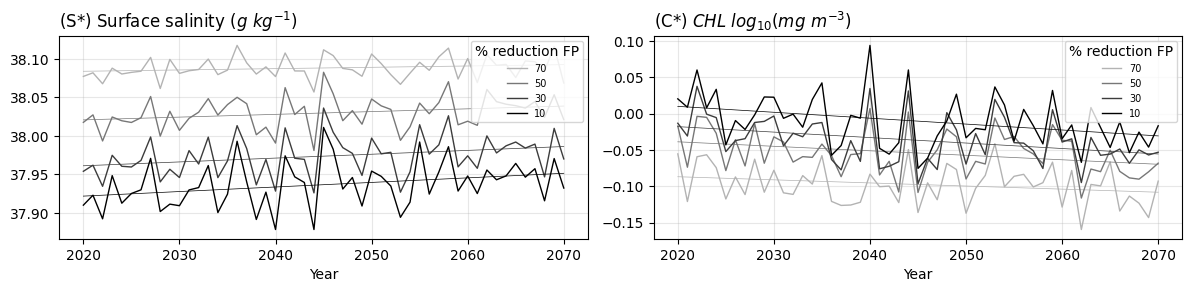

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [63]:

from google.colab import files
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

period_ia = np.arange(2020, 2070 + 1)
rcpchoice = RCP_CHOICE
ADJ_keep = [0.3, 0.5, 0.7, 0.9]

fig, axs = plt.subplots(1, 2, figsize=(12, 3))

cmap_black_grey = LinearSegmentedColormap.from_list(
    "grey_black",
    [(0.0, (0.7, 0.7, 0.7)), (1.0, (0.0, 0.0, 0.0))]
)

colors = cmap_black_grey(np.linspace(0, 1, len(ADJFAC_FR_LIST)))

for iadj, ADJ in enumerate(ADJFAC_FR_LIST):

    if not any(np.isclose(ADJ, v) for v in ADJ_keep):
        continue

    RED_pct = 100 * (1 - ADJ)

    col = colors[iadj]
    lw = 1
    alp = 1

    proj_rcp45 = OUT[ADJ]["proj_rcp45"]
    proj_rcp85 = OUT[ADJ]["proj_rcp85"]

    if rcpchoice == 45:
        S_ia = beaning(np.array(proj_rcp45["S*"]), period_ia, yyyy_cmcc)
        C_ia = beaning(np.array(proj_rcp45["CHL_RF"]), period_ia, yyyy_cmcc)
    else:
        S_ia = beaning(np.array(proj_rcp85["S*"]), period_ia, yyyy_cmcc)
        C_ia = beaning(np.array(proj_rcp85["CHL_RF"]), period_ia, yyyy_cmcc)

    _, _, _, _, _, _, _, SL_S, _, IT_S = get_means_and_trends(period_ia, S_ia, False, 3, False)
    _, _, _, _, _, _, _, SL_C, _, IT_C = get_means_and_trends(period_ia, C_ia, False, 3, False)

    S_fit = SL_S * period_ia + IT_S
    C_fit = SL_C * period_ia + IT_C

    label = f"{RED_pct:.0f}"

    axs[0].plot(period_ia, S_ia, color=col, linestyle="-", label=label, linewidth=lw, alpha=alp)
    axs[0].plot(period_ia, S_fit, color=col, linestyle="-", linewidth=lw / 2, alpha=alp)

    axs[1].plot(period_ia, C_ia, color=col, linestyle="-", label=label, linewidth=lw, alpha=alp)
    axs[1].plot(period_ia, C_fit, color=col, linestyle="-", linewidth=lw / 2, alpha=alp)

axs[0].set_xlabel("Year")
axs[1].set_xlabel("Year")

axs[0].set_title(r"(S*) Surface salinity $(g \ kg^{-1})$",loc='left')
axs[1].set_title(r"(C*) $CHL$ $log_{10}(mg \ m^{-3})$",loc='left')

axs[0].grid(alpha=0.3)
axs[1].grid(alpha=0.3)

axs[0].legend(title=r"% reduction FP", loc=1, fontsize=7)
axs[1].legend(title=r"% reduction FP", loc=1, fontsize=7)

fig.tight_layout(pad=1)

fig_filename = "FIGURE_PROJ_S_C_reductionFP_rcp" + str(rcpchoice) + ".png"
fig.savefig(fig_filename, dpi=600, bbox_inches="tight")
plt.show()

files.download(fig_filename)

In [60]:
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt

def plot_slope_vs_reduction(OUT, ADJFAC_FR_LIST, yyyy_cmcc,
                            varstr="S", rcp="45", clr="k", dpi=600):

    period_ia = np.arange(2020, 2070 + 1)

    SLs = np.full(len(ADJFAC_FR_LIST), np.nan)
    SEs = np.full(len(ADJFAC_FR_LIST), np.nan)
    PVs = np.full(len(ADJFAC_FR_LIST), np.nan)

    RED_pct = 100 * (1 - np.array(ADJFAC_FR_LIST))

    for i, ADJ in enumerate(ADJFAC_FR_LIST):

        proj = OUT[ADJ][f"proj_rcp{rcp}"]

        if varstr == "S":
            yy = beaning(np.array(proj["S*"]), period_ia, yyyy_cmcc)
        elif varstr == "C":
            yy = beaning(np.array(proj["CHL_RF"]), period_ia, yyyy_cmcc)
        else:
            raise ValueError("varstr must be 'S' or 'C'")

        MEA, MED, MAX, MIN, STD, R2, PV, SL, SE, IT = get_means_and_trends(
            period_ia, yy, False, 3, False
        )

        SLs[i] = SL
        SEs[i] = SE
        PVs[i] = PV

    order = np.argsort(RED_pct)

    RED_pct = RED_pct[order]
    SLs = SLs[order]
    SEs = SEs[order]
    PVs = PVs[order]

    fig, ax = plt.subplots(1, 1, figsize=(5, 2.5))

    ax.plot(RED_pct, SLs, color=clr)
    ax.fill_between(RED_pct, SLs - SEs, SLs + SEs, color=clr, alpha=0.2)

    ax.set_xlabel("% reduction FP")
    ax.set_title(f"({varstr}*) Slope", color=clr,loc='left')
    ax.tick_params(axis="y", labelcolor=clr)
    ax.grid(alpha=0.3)

    ax2 = ax.twinx()
    ax2.plot(RED_pct, PVs, color="gray", alpha=0.5)
    ax2.set_ylabel("p-value", color="gray")
    ax2.tick_params(axis="y", labelcolor="gray")
    ax2.set_ylim(0, max(0.05, np.nanmax(PVs) * 1.1))

    #ax.set_title(f"{varstr}*, RCP{rcp}")

    fig.tight_layout(pad=1)

    fig_filename = f"FIGURE_PROJ_slope_{varstr}_{rcp}_reduction.png"
    fig.savefig(fig_filename, dpi=dpi, bbox_inches="tight")
    plt.show()

    files.download(fig_filename)

    return SLs, SEs, PVs

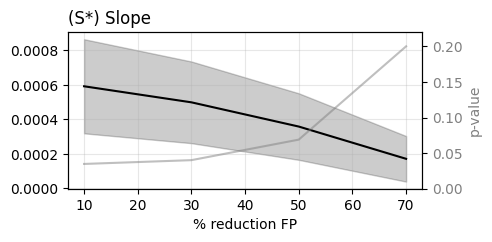

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

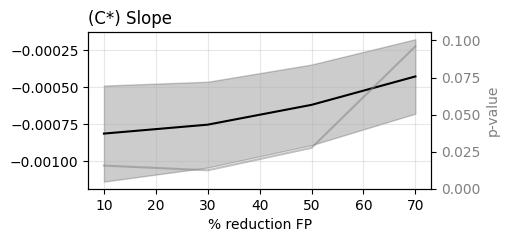

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [64]:
SLs_S, SEs_S, PVs_S = plot_slope_vs_reduction(
    OUT, ADJFAC_FR_LIST, yyyy_cmcc,
    varstr="S", rcp=str(RCP_CHOICE), clr='k', dpi=600) #clr_sal

SLs_S, SEs_S, PVs_S = plot_slope_vs_reduction(
    OUT, ADJFAC_FR_LIST, yyyy_cmcc,
    varstr="C", rcp=str(RCP_CHOICE), clr='k', dpi=600) #clr_chl

In [65]:
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import gaussian_kde

def plot_pdf_vs_reduction(OUT, ADJFAC_FR_LIST, yyyy_cmcc, wy_cmcc,
                          varstr="C", rcp="45", clr="k",
                          metric="median", season="all",
                          WITHMETRIC=False, bw=0.3, dpi=600):

    def get_season_mask(wy, season):
        ww = np.array(wy)
        if season == "all":
            return np.isfinite(ww)
        if season in ["winter", "DJF"]:
            return (ww >= 49) | (ww <= 9)
        if season in ["spring", "MAM"]:
            return (ww >= 10) & (ww <= 22)
        if season in ["summer", "JJA"]:
            return (ww >= 23) & (ww <= 35)
        if season in ["autumn", "SON"]:
            return (ww >= 36) & (ww <= 48)
        raise ValueError("wrong season")

    if WITHMETRIC:
        fig, axs = plt.subplots(1, 2, figsize=(7, 3), gridspec_kw={"width_ratios": [2, 1]})
        ax, axm = axs
    else:
        fig, ax = plt.subplots(1, 1, figsize=(5, 2.5))
        axm = None

    MET = np.full(len(ADJFAC_FR_LIST), np.nan)
    KS = np.full(len(ADJFAC_FR_LIST), np.nan)
    PV = np.full(len(ADJFAC_FR_LIST), np.nan)

    mask_season = get_season_mask(wy_cmcc, season)

    RED_pct = 100 * (1 - np.array(ADJFAC_FR_LIST, dtype=float))
    prev_yy = None

    all_vals = []

    for ADJ in ADJFAC_FR_LIST:
        proj = OUT[ADJ][f"proj_rcp{rcp}"]

        if varstr == "S":
            yy = np.array(proj["S*"])
        elif varstr == "C":
            yy = np.array(proj["CHL_RF"])
        else:
            raise ValueError("varstr must be 'S' or 'C'")

        yy = yy[mask_season]
        yy = yy[np.isfinite(yy)]

        if len(yy) > 2:
            all_vals.append(yy)

    xmin = np.nanmin([np.nanmin(v) for v in all_vals])
    xmax = np.nanmax([np.nanmax(v) for v in all_vals])
    xx = np.linspace(xmin, xmax, 300)

    for i, ADJ in enumerate(ADJFAC_FR_LIST):
        proj = OUT[ADJ][f"proj_rcp{rcp}"]

        if varstr == "S":
            yy = np.array(proj["S*"])
        elif varstr == "C":
            yy = np.array(proj["CHL_RF"])

        yy = yy[mask_season]
        yy = yy[np.isfinite(yy)]

        if len(yy) < 3 or np.nanstd(yy) == 0:
            continue

        kde = gaussian_kde(yy, bw_method=bw)
        ax.plot(xx, kde(xx), color=clr, alpha=ADJ, lw=2, label=f"{RED_pct[i]:.0f}")

        if metric == "mean":
            MET[i] = np.nanmean(yy)
        elif metric == "median":
            MET[i] = np.nanmedian(yy)
        else:
            raise ValueError("metric must be 'mean' or 'median'")

        if prev_yy is not None:
            KS[i], PV[i] = stats.ks_2samp(prev_yy, yy)

        prev_yy = yy

    if varstr == 'C':
        ax.set_xlabel(r"(C*) $CHL$ $log_{10}(mg \ m^{-3})$")
    elif varstr == 'S':
        ax.set_xlabel(r"(S*) Surface salinity $(g \ kg^{-1})$")


    ax.set_ylabel(f"Density")
    #ax.set_title(f"RCP{rcp} - {season}")
    #ax.set_title(f"{varstr}*, RCP{rcp}")
    ax.grid(alpha=0.3)
    ax.legend(title="% reduction FP", fontsize=7, loc=0)

    if WITHMETRIC:
        order = np.argsort(RED_pct)
        for j in order:
            axm.plot(RED_pct[j], MET[j], "o", color=clr, alpha=ADJFAC_FR_LIST[j])
        axm.set_xlabel("% reduction FP")
        axm.set_title(metric)
        axm.grid(alpha=0.3)

    fig.tight_layout(pad=1)

    fig_filename = f"FIGURE_PROJ_pdf_reduction_{metric}_{varstr}_rcp{rcp}_{season}.png"
    fig.savefig(fig_filename, dpi=dpi, bbox_inches="tight")
    plt.show()

    files.download(fig_filename)

    return MET, KS, PV

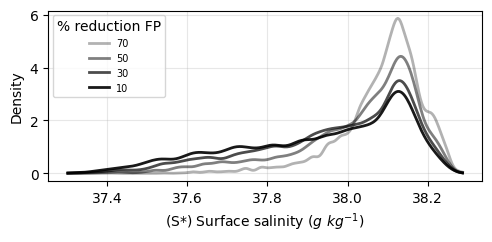

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

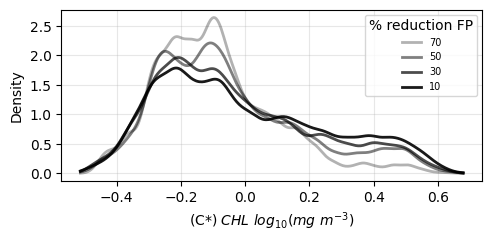

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [66]:
MET, KS, PV = plot_pdf_vs_reduction(
    OUT, ADJFAC_FR_LIST, yyyy_cmcc, wy_cmcc,
    varstr="S", rcp=str(RCP_CHOICE), season="all",
    WITHMETRIC=False, bw=0.1, dpi=600,clr='k')#clr_sal

MET, KS, PV = plot_pdf_vs_reduction(
    OUT, ADJFAC_FR_LIST, yyyy_cmcc, wy_cmcc,
    varstr="C", rcp=str(RCP_CHOICE), season="all",
    WITHMETRIC=False, bw=0.1, dpi=600,clr='k')#clr_chl

### PRIMARY PROD

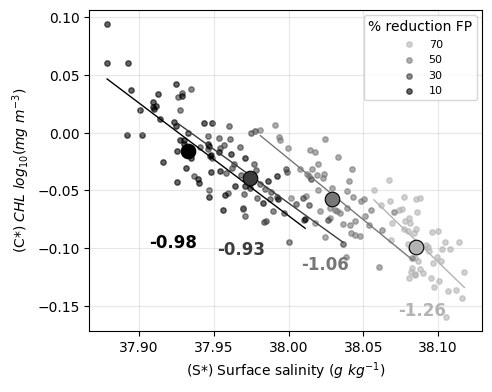

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [67]:
from google.colab import files
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

period_ia = np.arange(2020, 2070 + 1)
rcpchoice = (RCP_CHOICE)
ADJ_keep = [0.3, 0.5, 0.7, 0.9]

fig, ax = plt.subplots(1, 1, figsize=(5, 4))

cmap_black_grey = LinearSegmentedColormap.from_list(
    "grey_black",
    [(0.0, (0.7, 0.7, 0.7)), (1.0, (0.0, 0.0, 0.0))]
)

colors = cmap_black_grey(np.linspace(0, 1, len(ADJFAC_FR_LIST)))

for iadj, ADJ in enumerate(ADJFAC_FR_LIST):

    if not any(np.isclose(ADJ, v) for v in ADJ_keep):
        continue

    RED_pct = 100 * (1 - ADJ)
    col = colors[iadj]

    proj = OUT[ADJ][f"proj_rcp{rcpchoice}"]

    S_proj = beaning(np.array(proj["S*"]), period_ia, yyyy_cmcc)
    C_proj = beaning(np.array(proj["CHL_RF"]), period_ia, yyyy_cmcc)

    f = np.isfinite(S_proj) & np.isfinite(C_proj)
    S_proj = S_proj[f]
    C_proj = C_proj[f]

    ax.scatter(S_proj, C_proj, color=col, alpha=0.6, s=15, label=f"{RED_pct:.0f}")

    if len(S_proj) > 5:
        coef = np.polyfit(S_proj, C_proj, 1)
        slope = coef[0]

        xfit = np.linspace(np.nanmin(S_proj), np.nanmax(S_proj), 50)
        yfit = coef[0] * xfit + coef[1]
        ax.plot(xfit, yfit, color=col, linewidth=1)

        Smed = np.nanmedian(S_proj)
        Cmed = np.nanmedian(C_proj)

        ax.scatter(Smed, Cmed, s=110, color=col, edgecolor="k", linewidth=0.8, zorder=5)

        dx = 0.01 * (np.nanmax(S_proj) - np.nanmin(S_proj))
        dy = 0.01 * (np.nanmax(C_proj) - np.nanmin(C_proj))

        ax.text(
            Smed - 20 * dx,
            Cmed - 50 * dy,
            f"{slope:.2f}",
            color=col,
            fontsize=12,
            weight="bold"
        )



ax.set_xlabel(r"(S*) Surface salinity $(g \ kg^{-1})$")
ax.set_ylabel(r"(C*) $CHL$ $log_{10}(mg \ m^{-3})$")
#ax.set_title(f"S* vs C* (RCP{rcpchoice})")
ax.grid(alpha=0.3)
ax.legend(title="% reduction FP", fontsize=8, loc="best")

fig.tight_layout(pad=1)

fig_filename = "FIGURE_SCATTER_S_vs_C_reductionFP_rcp" + str(rcpchoice) + ".png"
fig.savefig(fig_filename, dpi=600, bbox_inches="tight")
plt.show()

files.download(fig_filename)

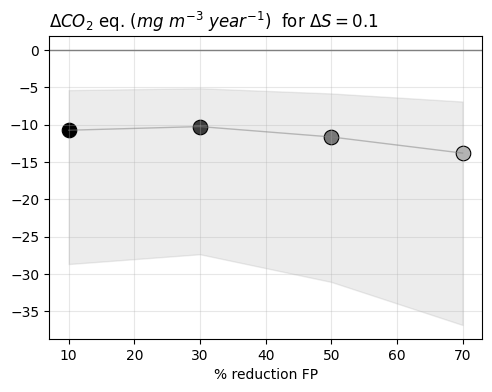

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [68]:
from google.colab import files
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

period_ia = np.arange(2020, 2070 + 1)

fig, ax = plt.subplots(1, 1, figsize=(5, 4))

cmap_black_grey = LinearSegmentedColormap.from_list(
    "grey_black",
    [(0.0, (0.7, 0.7, 0.7)), (1.0, (0.0, 0.0, 0.0))]
)

colors = cmap_black_grey(np.linspace(0, 1, len(ADJFAC_FR_LIST)))

rcpchoice = (RCP_CHOICE)
dS_ref = 0.1
ratio_ref = 30
ratio_min = 15
ratio_max = 80

ADJ_keep = [0.3, 0.5, 0.7, 0.9]

RED_list = []
DCO2_ref_list = []
DCO2_min_list = []
DCO2_max_list = []
COLOR_list = []

for iadj, ADJ in enumerate(ADJFAC_FR_LIST):

    if not any(np.isclose(ADJ, v) for v in ADJ_keep):
        continue

    RED_pct = 100 * (1 - ADJ)
    col = colors[iadj]

    proj = OUT[ADJ][f"proj_rcp{rcpchoice}"]

    S_proj = beaning(np.array(proj["S*"]), period_ia, yyyy_cmcc)
    C_proj = beaning(np.array(proj["CHL_RF"]), period_ia, yyyy_cmcc)

    f = np.isfinite(S_proj) & np.isfinite(C_proj)
    S_proj = S_proj[f]
    C_proj = C_proj[f]

    if len(S_proj) > 5:
        coef = np.polyfit(S_proj, C_proj, 1)
        slope = coef[0]

        dCHL_ref = slope * dS_ref
        dCO2_ref = dCHL_ref * ratio_ref * 44 / 12
        dCO2_min = dCHL_ref * ratio_min * 44 / 12
        dCO2_max = dCHL_ref * ratio_max * 44 / 12

        RED_list.append(RED_pct)
        DCO2_ref_list.append(dCO2_ref)
        DCO2_min_list.append(dCO2_min)
        DCO2_max_list.append(dCO2_max)
        COLOR_list.append(col)

RED_arr = np.array(RED_list)
DCO2_ref_arr = np.array(DCO2_ref_list)
DCO2_min_arr = np.array(DCO2_min_list)
DCO2_max_arr = np.array(DCO2_max_list)
COLOR_arr = np.array(COLOR_list)

order = np.argsort(RED_arr)

RED_arr = RED_arr[order]
DCO2_ref_arr = DCO2_ref_arr[order]
DCO2_min_arr = DCO2_min_arr[order]
DCO2_max_arr = DCO2_max_arr[order]
COLOR_arr = COLOR_arr[order]

ax.fill_between(RED_arr, DCO2_min_arr, DCO2_max_arr, color="gray", alpha=0.15)
ax.plot(RED_arr, DCO2_ref_arr, "-", color="gray", lw=1, alpha=0.5)

for i in range(len(RED_arr)):
    #ax.plot(RED_arr[i], DCO2_ref_arr[i], "o", color=COLOR_arr[i], ms=8)
    ax.scatter(RED_arr[i], DCO2_ref_arr[i], s=110, color=COLOR_arr[i], edgecolor="k", linewidth=0.8,)
ax.axhline(0, color="0.5", lw=1)

ax.set_xlabel("% reduction FP")
ax.set_title(
    r"$\Delta CO_2$ eq. $(mg \ m^{-3} \ year^{-1})$"
    + "  "
    + fr"for $\Delta S={dS_ref}$", loc='left'
)
#ax.set_title(f"RCP{RCP_CHOICE}")
ax.grid(alpha=0.3)

fig.tight_layout(pad=1)

fig_filename = f"FIGURE_DCO2eq_reductionFP_rcp{rcpchoice}.png"
fig.savefig(fig_filename, dpi=600, bbox_inches="tight")
plt.show()

files.download(fig_filename)
